# Diffusion - Mouvement Brownien

Python est l'un des langages de programmation les plus utilisés dans de nombreux domaines. Il est apprécié pour sa syntaxe proche de l'anglais courant.

Nous utiliserons un notebook, c'est-à-dire un document permettant d'écrire du texte et d'exécuter du code en visualisant immédiatement les résultats. Contrairement à un script classique, il n'est pas nécessaire d'exécuter l'ensemble du code en une seule fois.

Commencez par transférer les fichiers dans un dossier Google Drive. Par exemple, créez un dossier nommé *TP_MecaPhys_Diffusion*, puis quatre sous-dossiers : *Sommerfeld*, *Particules_r050*, *Particules_r075* et *Particules_r100*. Placez-y vos images.

Rendez-vous sur Google Colab : https://colab.research.google.com  
Cliquez sur « GitHub », puis collez l'adresse suivante :  

http://github.com/shoyip/TP_MecaPhys_Brownien

Sélectionnez le notebook *TP_MecaPhys_Brownien.ipynb*, puis cliquez sur « File » > « Save a copy in Drive ». Une nouvelle fenêtre s'ouvre.

Exécutez la cellule suivante avec « Shift + Enter ». Une fenêtre s'ouvre : cliquez sur « Connect to Google Drive », puis sur « Continue » deux fois.

In [220]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Le Google Drive est maintenant monté. Dans le volet « Files », accédez à « drive » > « MyDrive ». Pour récupérer le chemin d'un dossier, cliquez sur les trois points à droite, puis sur « Copy path ».

Définissez ensuite le chemin du dossier racine contenant les fichiers.

In [221]:
chemin_donnees_string = "/content/drive/MyDrive/TP_MecaPhys_Diffusion"

On peut utiliser l'outil *Path* de la librairie *pathlib* pour la gestion des chemins des fichiers.

In [222]:
from pathlib import Path

In [223]:
chemin_donnees = Path(chemin_donnees_string)

Pour acceder au sous-dossier on peut juste ajouter "/" et le nom du sous-dossier entre guillemets.

On peut trouver tous les fichiers qui respectent des régles avec la méthode
*glob*.

Il vous suffit de savoir que "*" signifie "tous les charactères". Donc "*.tiff" veut dire "tous les fichier qui finissent en .tiff".

In [224]:
chemin_r050 = chemin_donnees / "Particules_r050"
fichiers_r050 = chemin_r050.glob("*.tiff")

De base les fichiers ne sont pas bien ordonnés. On veut extraire donc pour chaque fichier le frame et on l'associe au fichier. On utilise un *dictionnaire* pour stocker ces données là.

In [225]:
# on initialise un dictionnaire vide
dictionnaire_frames = {}

# on boucle sur la liste des fichiers
for fichier in fichiers_r050:
  # on extrait l'indice du frame:
  # 1) on extrait juste le nom du fichier sans extension (.stem)
  # 2) on divise le nom du fichier en parts divisés par "-"
  # 3) on prend que la dernière part
  # 4) on s'assure que ça soit un nombre entier
  indice_frame = int(fichier.stem.split("-")[-1])
  # on garde chemin du fichier
  chemin_fichier = str(fichier)
  # on associe le numéro de frame au chemin du fichier
  dictionnaire_frames[indice_frame] = chemin_fichier

Le dictionnaire a cette tete là.

In [226]:
print(dictionnaire_frames)

{5: '/content/drive/MyDrive/TP_MecaPhys_Diffusion/Particules_r050/temp-02172026142047-5.tiff', 3: '/content/drive/MyDrive/TP_MecaPhys_Diffusion/Particules_r050/temp-02172026142046-3.tiff', 9: '/content/drive/MyDrive/TP_MecaPhys_Diffusion/Particules_r050/temp-02172026142047-9.tiff', 1: '/content/drive/MyDrive/TP_MecaPhys_Diffusion/Particules_r050/temp-02172026142046-1.tiff', 7: '/content/drive/MyDrive/TP_MecaPhys_Diffusion/Particules_r050/temp-02172026142047-7.tiff', 10: '/content/drive/MyDrive/TP_MecaPhys_Diffusion/Particules_r050/temp-02172026142047-10.tiff', 13: '/content/drive/MyDrive/TP_MecaPhys_Diffusion/Particules_r050/temp-02172026142047-13.tiff', 8: '/content/drive/MyDrive/TP_MecaPhys_Diffusion/Particules_r050/temp-02172026142047-8.tiff', 12: '/content/drive/MyDrive/TP_MecaPhys_Diffusion/Particules_r050/temp-02172026142047-12.tiff', 2: '/content/drive/MyDrive/TP_MecaPhys_Diffusion/Particules_r050/temp-02172026142046-2.tiff', 11: '/content/drive/MyDrive/TP_MecaPhys_Diffusion/Par

Maintenant les fichiers sont ordonnés par numéro de frame.

On peut essayer d'importer le premier fichier. On y accède en choisissant l'element 0 du dictionnaire `dictionnaire_frames`.

In [227]:
dictionnaire_frames[0]

'/content/drive/MyDrive/TP_MecaPhys_Diffusion/Particules_r050/temp-02172026142046-0.tiff'

Pour l'importer on a besoin de la librairie OpenCV. On peut l'inclure dans le notebook en executant la prochaine cellule.

In [228]:
import cv2

On utilise la méthode `imread` pour lire l'image en tant que matrice.

In [229]:
image_exemple = cv2.imread(
    filename = dictionnaire_frames[0],
    flags = cv2.IMREAD_GRAYSCALE
).astype("uint16")

Pour manipuler ces matrices on a besoin de la librairie NumPy.

Pour visualiser les images et générer des plots on a besoin de la librairie Maptlotlib PyPlot.

On va importer les deux librairies.

In [230]:
import numpy as np
import matplotlib.pyplot as plt

On utilise la méthode `plt.figure` pour créer la figure, `plt.imshow` pour visualiser l'image, et `plt.show` pour l'afficher sur l'écran.

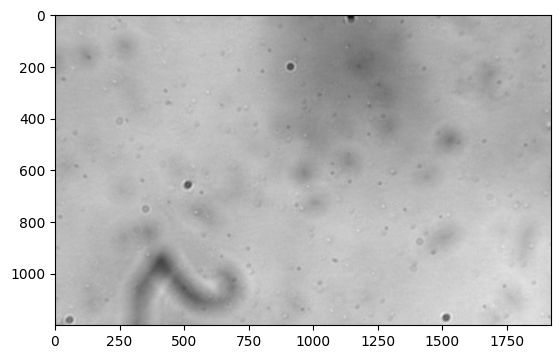

In [231]:
fig = plt.figure()
plt.imshow(
    image_exemple,
    cmap = "gray"
)
plt.show()

Nous voyons les particules, mais surtout le fond. Si on suppose que le fond ne change pas de frame en frame, on peut penser de faire une moyenne et de substraire la moyenne à chaque image.

Pour faire ça on commence par créer une image completement vide avec les memes dimensions que l'image d'exemple, boucler sur toutes les images et sommer les valeurs. Après on obtient la moyenne en divisant par le nombre d'images.

In [232]:
somme_images = np.zeros(image_exemple.shape)

for indice_frame, fichier_frame in dictionnaire_frames.items():
  somme_images = somme_images + cv2.imread(filename = fichier_frame, flags = cv2.IMREAD_GRAYSCALE)

moyenne_images = (somme_images / len(dictionnaire_frames))

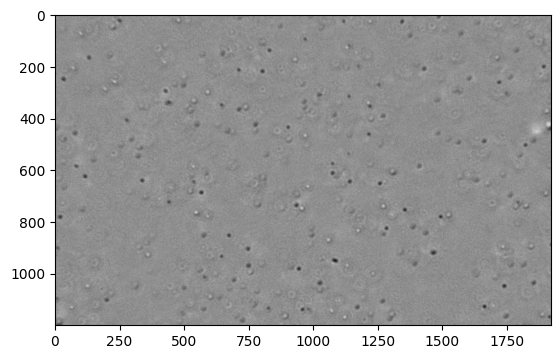

In [233]:
image_demoyenne = image_exemple - moyenne_images

fig = plt.figure()
plt.imshow(
    image_demoyenne,
    cmap = "gray"
)
plt.show()

On voit beaucoup mieux les particules.

Pour eliminer des inhomogénéités locales on peut utiliser la méthode `cv2.GaussianBlur`, où on indique la taille du blur et le centre.

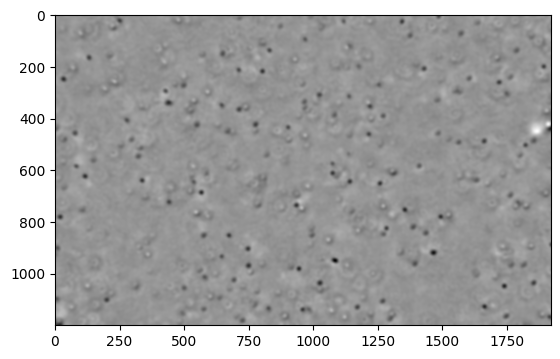

In [234]:
image_flou = cv2.GaussianBlur(image_demoyenne, (33, 33), 0)

fig = plt.figure()
plt.imshow(
    image_flou,
    cmap = "gray"
)
plt.show()

Regards-on la distribution des valeurs de la matrice image.

On utilise la méthode `.ravel()` pour transformer une matrice dans un vecteur unidimensionel. Après on applique la méthode `plt.hist` pour avoir un histogram des valeurs.

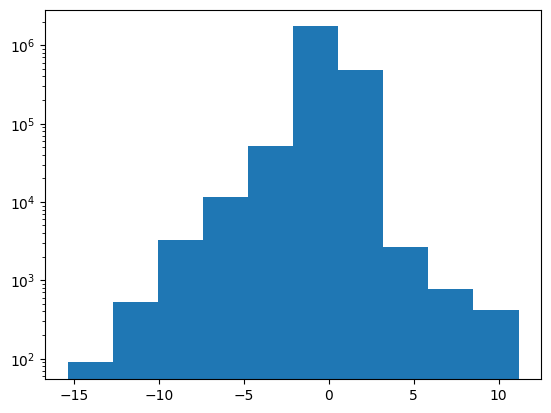

In [235]:
fig = plt.figure()
plt.hist(image_flou.ravel())
plt.yscale("log")
plt.show()

Nous pouvons maintenant seuiller l'image en choisissant une valeur dans la distribution, et voyant l'effet provoqué.

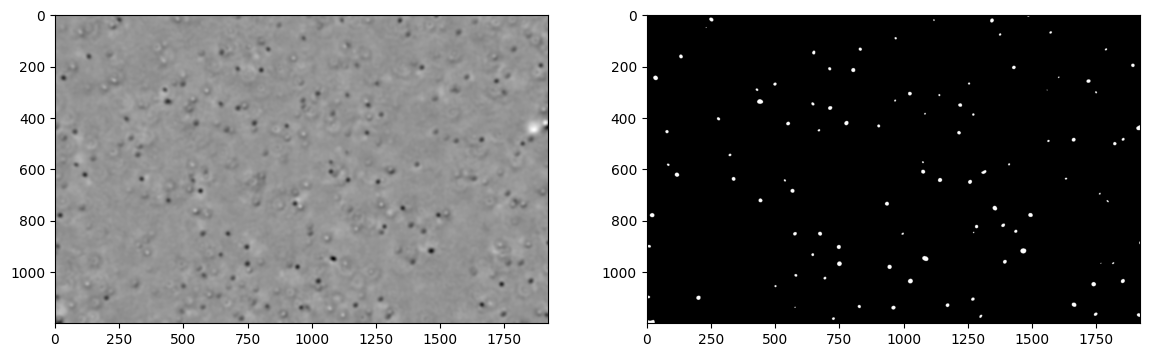

In [236]:
seuil_intensite = -5
image_binaire = (image_flou < seuil_intensite).astype(np.uint8) * 255

fig, axs = plt.subplots(1, 2, figsize=(14, 6))
axs[0].imshow(
    image_flou,
    cmap = "gray"
)
axs[1].imshow(
    image_binaire,
    cmap = "gray"
)
plt.show()

Nous voyons que nous obtenions des resultats très hétérogènes.

On veut alors filtrer les particules par taille.



In [237]:
contours, _ = cv2.findContours(image_binaire, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)
aires = []

for contour in contours:
  aire = cv2.contourArea(contour)
  aires.append(aire)

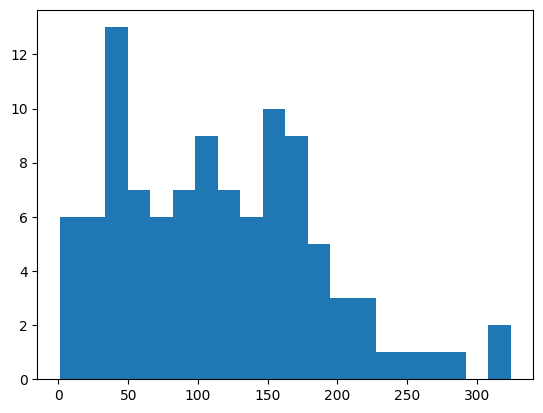

In [238]:
fig = plt.figure()
plt.hist(aires, bins=20)
plt.show()

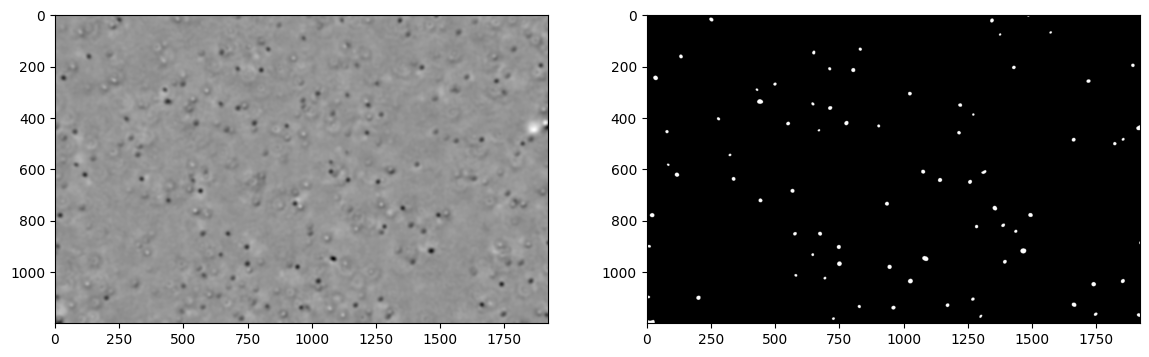

In [239]:
seuil_aire = 50
image_filtre_surface = np.zeros_like(image_binaire)

for i, contour in enumerate(contours):
    aire = aires[i]
    if aire > seuil_aire:
        cv2.drawContours(image_filtre_surface, [contour], -1, 255, -1)

fig, axs = plt.subplots(1, 2, figsize=(14, 6))
axs[0].imshow(
    image_flou,
    cmap = "gray"
)
axs[1].imshow(
    image_filtre_surface,
    cmap = "gray"
)
plt.show()

Maintenant on peut noter les positions $(x,y)$ des particules. On extrait ces informations à partir des *moments* des contours.

In [240]:
particules = []

for contour in contours:
  aire = cv2.contourArea(contour)
  if aire > seuil_aire:
    M = cv2.moments(contour)
    if M["m00"] > 0:
      cx = M["m10"] / M["m00"]
      cy = M["m01"] / M["m00"]
      particules.append((cx, cy))

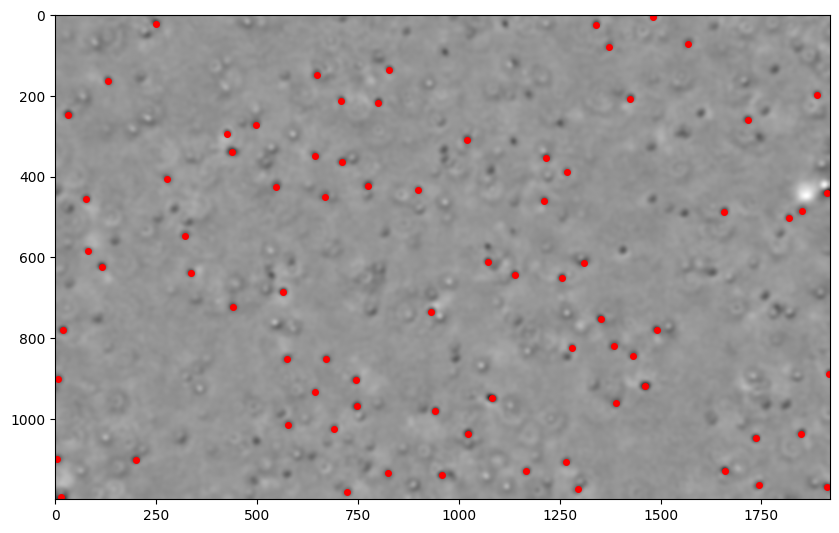

In [241]:
fig = plt.figure(figsize=(10, 8))
plt.imshow(
    image_flou,
    cmap = "gray"
)

for cx, cy in particules:
    plt.plot(cx, cy, 'ro', markersize=4)

plt.show()

On peut donc enchainer le code qu'on a écrit dans une fonction que puisse etre appliqué à toutes autres frames.

In [242]:
def trouver_dictionnaire(dossier_frames):
  chemin_frames = Path(dossier_frames)
  fichiers_frames = chemin_frames.glob("*.tiff")
  dictionnaire_frames = {}

  for fichier in fichiers_frames:
    indice_frame = int(fichier.stem.split("-")[-1])
    chemin_fichier = str(fichier)
    dictionnaire_frames[indice_frame] = chemin_fichier

  return dictionnaire_frames

def trouver_moyenne(dictionnaire_frames):
  # Get the first frame's path for image dimensions
  first_frame_path = dictionnaire_frames[min(dictionnaire_frames.keys())]
  premiere_image = cv2.imread(filename = first_frame_path, flags = cv2.IMREAD_GRAYSCALE)
  somme_images = np.zeros(premiere_image.shape, dtype=np.float64)

  for fichier_frame in dictionnaire_frames.values():
    somme_images = somme_images + cv2.imread(filename = fichier_frame, flags = cv2.IMREAD_GRAYSCALE)

  moyenne_images = (somme_images / len(dictionnaire_frames))

  return moyenne_images

def trouver_particules(dictionnaire_frames, taille_flou, seuil_intensite, seuil_aire):
  moyenne_images = trouver_moyenne(dictionnaire_frames)
  particules = []
  #frames_ordonnes = sorted(dictionnaire_frames.items(), key=lambda item: item[0])

  for indice_frame, fichier_frame in dictionnaire_frames.items():
    image_frame = cv2.imread(filename = fichier_frame, flags = cv2.IMREAD_GRAYSCALE)
    image_demoyenne = image_frame - moyenne_images
    kernel_size = (taille_flou, taille_flou) if taille_flou % 2 != 0 else (taille_flou + 1, taille_flou + 1)
    image_flou = cv2.GaussianBlur(image_demoyenne, kernel_size, 0)
    image_binaire = (image_flou < seuil_intensite).astype(np.uint8) * 255

    contours, _ = cv2.findContours(image_binaire, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)

    for contour in contours:
      aire = cv2.contourArea(contour)
      if aire > seuil_aire:
        M = cv2.moments(contour)
        if M["m00"] > 0:
          cx = M["m10"] / M["m00"]
          cy = M["m01"] / M["m00"]
          particules.append((indice_frame, cx, cy))

  return particules

In [243]:
dictionnaire_frames = trouver_dictionnaire("/content/drive/MyDrive/TP_MecaPhys_Diffusion/Particules_r050")

particules = trouver_particules(
    dictionnaire_frames = dictionnaire_frames,
    taille_flou = 33,
    seuil_intensite = -5,
    seuil_aire = 50
)

In [244]:
print(particules)

[(5, 19.461762988908347, 1192.3082311733801), (5, 1913.5123216601814, 1144.8417639429313), (5, 936.0147058823529, 1143.952205882353), (5, 811.1167369901547, 1138.7032348804498), (5, 1154.318224740321, 1131.3975448536355), (5, 1678.5567375886526, 1122.936170212766), (5, 205.86855941114615, 1110.0967402733963), (5, 1267.0433333333333, 1098.5166666666667), (5, 1866.580404685836, 1031.1171458998933), (5, 1026.9092592592592, 1029.625), (5, 1729.7055435565153, 1029.4823614110871), (5, 695.948275862069, 1020.5402298850574), (5, 594.6547619047619, 1001.8962585034013), (5, 924.2796474358973, 978.0625), (5, 1382.487341772152, 971.6392405063291), (5, 758.7066666666666, 958.8475), (5, 1075.039786511402, 955.5681707908781), (5, 633.1566054243219, 926.9002624671916), (5, 5.329573934837092, 912.5112781954887), (5, 1464.1486486486488, 908.1448948948948), (5, 715.1867671691792, 902.6172529313232), (5, 1914.0813559322035, 877.341242937853), (5, 991.4137115839242, 870.7754137115838), (5, 664.644110275689

On obtient une liste de toutes les particules en format $(i_\text{frame}, x, y)$.

La librairie pour le tracking qu'on va utiliser, qui s'appelle TrackPy, accepte en input que des DataFrame Pandas. Pandas c'est une librairie très pratique pour les données en format tabulaire.

In [245]:
import pandas as pd

On peut vite fait convertir la liste dans un DataFrame en utilisant la méthode `pd.DataFrame`

In [246]:
df_particules = pd.DataFrame(particules)
df_particules.columns = ["frame", "x", "y"]
print(df_particules)

      frame            x            y
0         5    19.461763  1192.308231
1         5  1913.512322  1144.841764
2         5   936.014706  1143.952206
3         5   811.116737  1138.703235
4         5  1154.318225  1131.397545
...     ...          ...          ...
7157     94  1452.134199    58.219913
7158     94   287.531250    37.140625
7159     94   998.060952    33.011429
7160     94   683.514599    32.220195
7161     94   200.395683    29.528777

[7162 rows x 3 columns]


*TrackPy* n'est pas disponible sur Google Colab et il faut donc l'installer.

Pour acceder à la ligne de commande il faut utiliser "!" d'abord et après indiquer la commande à envoyer.

On utilise la commande `pip install nomlibrairie` pour installer des nouvelles librairies.

On peut utiliser l'option `-q` (quiet) pour ne pas afficher trop d'informations.

In [247]:
!pip install -q trackpy


On import les méthodes de la librairie *TrackPy*.

In [248]:
import trackpy as tp

On peut utiliser la méthode `tp.link` pour reconnaitre les particules d'un frame à un autre. On obtient un DataFrame qui a une nouvelle colomne `particle`, qui donne un nombre entier comme identificatif d'une particule.

Le paramètre `search_range` indique la distance maximale (en pixel pour l'instant) pour lier deux particules à un frame de distance. Le paramètre `memory` indique le nombre de frames où on peut avoir une perte de detection de particule mais quand meme garder l'information sur la particule.

In [249]:
df_trajectoires = tp.link(df_particules, search_range=20, memory=3)

Frame 100: 73 trajectories present.


On peut voir les figures des trajectoires avec la méthode `tp.plot_traj`.

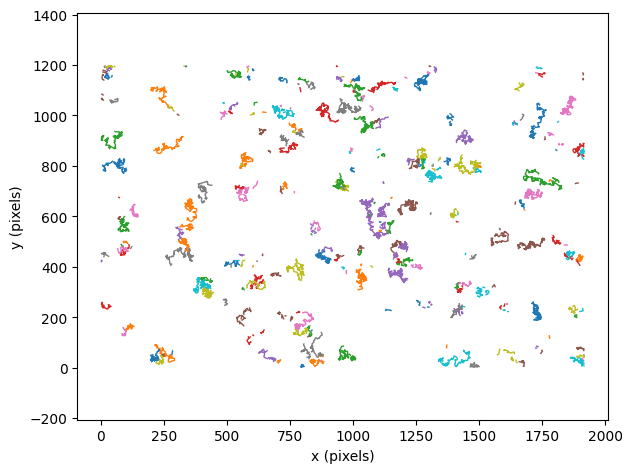

In [250]:
fig, ax = plt.subplots()
tp.plot_traj(df_trajectoires, ax=ax)
ax.set_xlabel("x (pixels)")
ax.set_ylabel("y (pixels)")
ax.invert_yaxis()
plt.tight_layout()
plt.axis('equal')
plt.show()

On voit qu'on a beaucoup de bouts de trajectoires qui sont très courts. On peut filtrer les trajectoires par longeur en definissant un seuil, et en utilisant la méthode `tp.filter_stubs`.

In [251]:
seuil_trajectoire = 20
df_trajectoires_seuille = tp.filter_stubs(df_trajectoires, seuil_trajectoire).reset_index(drop=True)

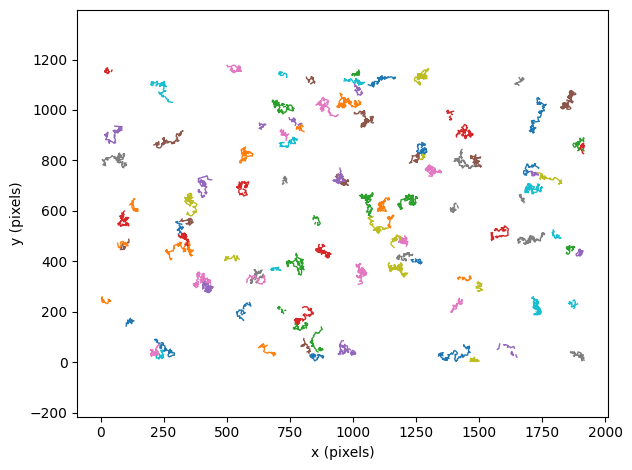

In [252]:
fig, ax = plt.subplots()
tp.plot_traj(df_trajectoires_seuille, ax=ax)
ax.set_xlabel("x (pixels)")
ax.set_ylabel("y (pixels)")
ax.invert_yaxis()
plt.tight_layout()
plt.axis('equal')
plt.show()

In [253]:
pixel_per_m = 10.6412e6

df_trajectoires_seuille["x"] = df_trajectoires_seuille["x"] / pixel_per_m
df_trajectoires_seuille["y"] = df_trajectoires_seuille["y"] / pixel_per_m

In [254]:
s_per_frame = 0.1

df_trajectoires_seuille["t"] = df_trajectoires_seuille["frame"] * s_per_frame

On a des trajectoires beaucoup plus propres.

Maintenant on veut calculer le *déplacement quadratique moyen* (*mean squared displacement* ou MSD en anglais).

La définition de déplacement quadratique moyen est la suivante:

$$
\text{MSD}(t; t_0) = \langle | \vec x(t) - \vec x(t_0) |^2 \rangle_\text{particules}
= \frac{1}{N} \sum_\text{particules} | \vec x(t) - \vec x(t_0) |^2
$$

Si on trace tous les déplacements moyens on obtiens la figure suivante.

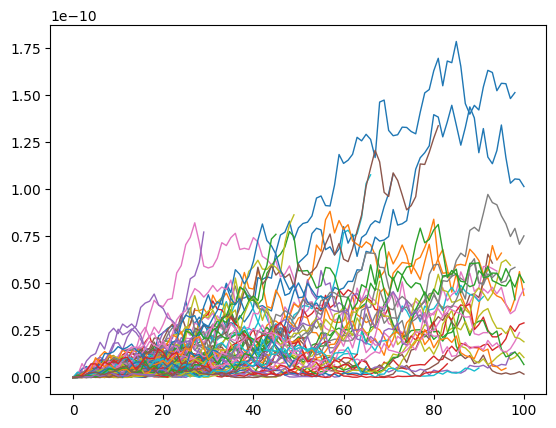

In [255]:
fig = plt.figure()
for i in df_trajectoires_seuille.particle.unique():
  matrices_positions = df_trajectoires_seuille.query(f"particle == {i}")[['x', 'y']].to_numpy()
  plt.plot(np.sum((matrices_positions - matrices_positions[0])**2, axis=1), '-', linewidth=1)
plt.show()

On peut alors tracer la moyenne.

In [256]:
df_trajectoires_seuille["deplacement_quadratique"] = df_trajectoires_seuille\
  .groupby("particle")[['x', 'y']]\
  .transform(lambda e: e - e.iloc[0])\
  .pow(2).sum(axis=1)

In [257]:
msd = df_trajectoires_seuille\
  .groupby("frame")["deplacement_quadratique"]\
  .mean()

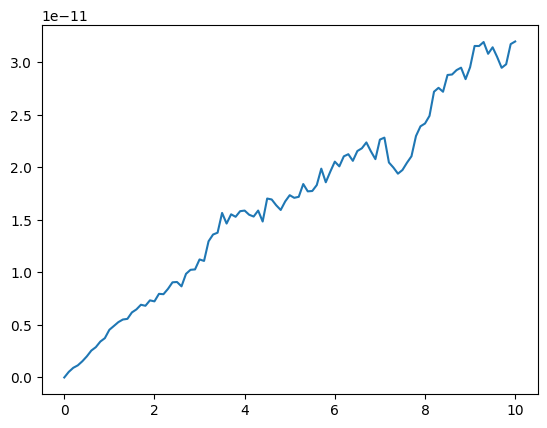

In [258]:
fig = plt.figure()
plt.plot(np.arange(len(msd)) * s_per_frame, msd)
plt.show()

Est-ce qu'on peut faire mieux?

Là on utilise qu'une partie des échantillons qu'on pourrait utiliser. On pourrait, par exemple, trouver le MSD pour chaque fenetre d'une unité de temps, de deux unités de temps, de trois unités de temps, ...

On peut calculer le MSD comme ça sous les assomptions suivants:

- Processus markoviens

$$
p(x\,t | x_o \, t_0) = p(x-x_0 \, t-t_0 | x_o \, t_0)
$$

- Processus stationnaires

$$
p(x\,t | x_o \, t_0) = p(x-x_0 \, t-t_0 | x_o)
$$

- Time and translationally invariant

$$
p(x\,t | x_o \, t_0) = p(x-x_0 \, t-t_0)
$$

In [259]:
def trouver_msd_fenetres(groupe):
    positions = groupe[['x', 'y']].values
    etapes_temps = len(positions)
    lags = np.arange(1, etapes_temps)
    msd_lags = [np.mean(np.sum((positions[lag:] - positions[:-lag])**2, axis=1)) for lag in lags]
    return pd.Series(msd_lags, index=pd.Index(lags, name='Delta_t'))

On a écrit une fonction pour trouver, pour les position regroupés par chaque particule, le MSD en fonction des *lags* $\Delta t$.

In [260]:
msd_per_particle = df_trajectoires_seuille.groupby('particle').apply(trouver_msd_fenetres, include_groups=False)
msd_wide = msd_per_particle.unstack(level='particle')
overall_msd = msd_wide.mean(axis=1).reset_index()
overall_msd.columns = ['Delta_t', 'MSD']

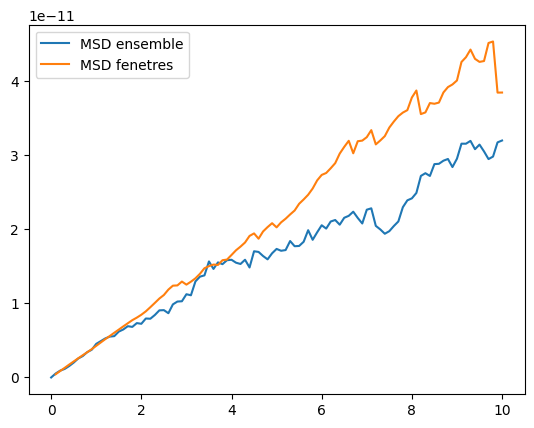

In [261]:
fig = plt.figure()
plt.plot(np.arange(len(msd)) * s_per_frame, msd, label="MSD ensemble")
plt.plot(overall_msd["Delta_t"] * s_per_frame, overall_msd["MSD"], label="MSD fenetres")
plt.legend()
plt.show()

In [262]:
!pip install -q scipy

In [263]:
from scipy.optimize import curve_fit

In [264]:
def fonction_lineaire(x, m, q):
  return m * x + q

def ajustement_lineaire_pente(x, y, indice_seuil):
  popt, pcov = curve_fit(fonction_lineaire, x[:indice_seuil], y[:indice_seuil])
  perr = np.sqrt(np.diag(pcov))
  m, q = popt
  merr, qerr = perr
  return q, qerr, m, merr

In [265]:
q_ensemble, qerr_ensemble, m_ensemble, merr_ensemble = ajustement_lineaire_pente(msd.index * s_per_frame, msd, 50)
q_fenetre, qerr_fenetre, m_fenetre, merr_fenetre = ajustement_lineaire_pente(overall_msd["Delta_t"] * s_per_frame, overall_msd["MSD"], 50)

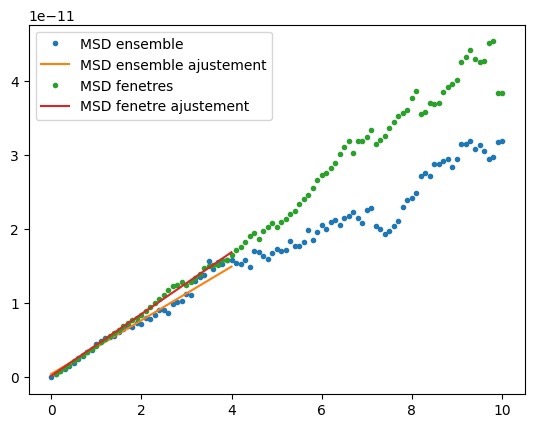

In [266]:
fig = plt.figure()
plt.plot(msd.index * s_per_frame, msd, ".", label="MSD ensemble")
plt.plot(np.arange(5), fonction_lineaire(np.arange(5), m_ensemble, q_ensemble), "-", label="MSD ensemble ajustement")
plt.plot(overall_msd["Delta_t"] * s_per_frame, overall_msd["MSD"], ".", label="MSD fenetres")
plt.plot(np.arange(5), fonction_lineaire(np.arange(5), m_fenetre, q_fenetre), "-", label="MSD fenetre ajustement")
plt.legend()
plt.show()

Comparer les resultats des ajustement avec les prévision théoriques.

In [267]:
m_ensemble / 4, m_fenetre / 4

(np.float64(9.069269467778393e-13), np.float64(1.0437994158997876e-12))

In [268]:
import math

In [269]:
kB = 1.38e-23
T = 298.15
eta = 1.0e-3
R_particule = 0.5e-6

D_theo = kB * T / (6 * math.pi * eta * R_particule)

In [270]:
D_theo

4.3655882580220716e-13